# Visual Story: Titanic Survival — 6 Charts

This notebook extends the lesson-1 Titanic EDA with six publication-quality
charts that build a survival story: **who lived, who didn't, and why.**

Each chart has a title, labelled axes, a deliberate colour choice, and a
one-line takeaway underneath it.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reuse the same Titanic dataset loaded in the lesson-1 notebook.
# If you saved it locally in lesson 1 (e.g. df.to_csv('titanic.csv')),
# point the fallback at that path so this notebook is self-contained.
try:
    df = sns.load_dataset('titanic')
except Exception:
    df = pd.read_csv('titanic.csv')  # <- update path if your lesson-1 file lives elsewhere

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Quick clean-up (same steps as lesson 1)

In [2]:
# Fill missing age with the median, missing embarkation with the mode
df['age'] = df['age'].fillna(df['age'].median())
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Engineer family size: self + siblings/spouses + parents/children
sibsp_col = 'sibsp' if 'sibsp' in df.columns else 'sibsp'
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Human-readable survival label for legends/titles
df['survived_label'] = df['survived'].map({0: 'Did not survive', 1: 'Survived'})

palette = {'Survived': '#2a9d8f', 'Did not survive': '#e76f51'}
df.shape


(891, 17)

## Chart 1 — Overall Survival Counts

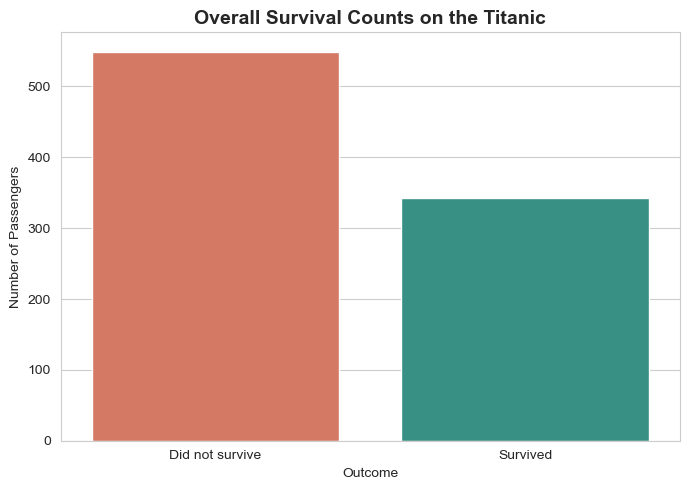

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='survived_label', hue='survived_label',
              palette=palette, legend=False, ax=ax)
ax.set_title('Overall Survival Counts on the Titanic', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Passengers')
plt.tight_layout()
plt.show()


*Takeaway: the majority of passengers on board did not survive.*

## Chart 2 — Survival Rate by Sex

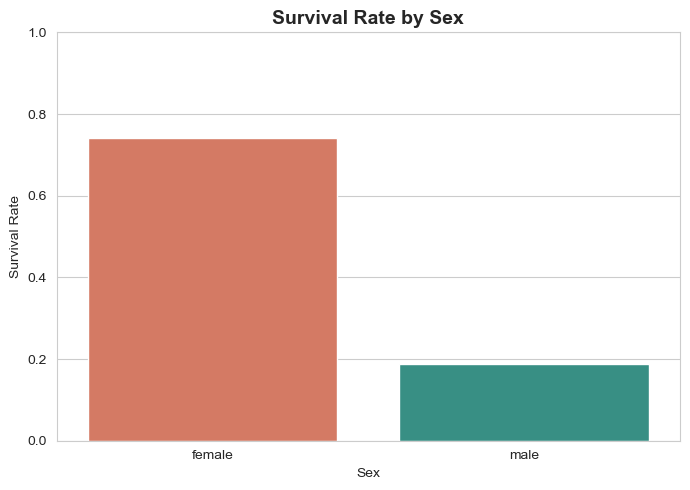

In [4]:
rate_sex = df.groupby('sex')['survived'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=rate_sex, x='sex', y='survived', hue='sex',
            palette=['#e76f51', '#2a9d8f'], legend=False, ax=ax)
ax.set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


*Takeaway: women survived at a dramatically higher rate than men, reflecting the 'women and children first' evacuation policy.*

## Chart 3 — Survival Rate by Passenger Class

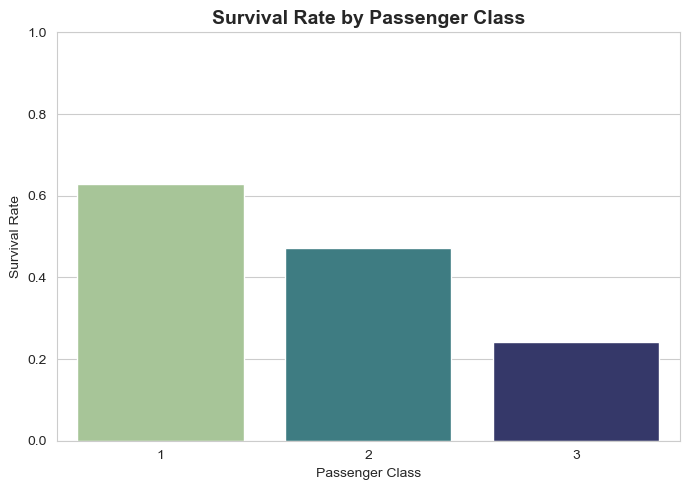

In [5]:
rate_class = df.groupby('pclass')['survived'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=rate_class, x='pclass', y='survived', hue='pclass',
            palette='crest', legend=False, ax=ax)
ax.set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


*Takeaway: survival rate drops sharply from first to third class, showing wealth and cabin location mattered.*

## Chart 4 — Age Distribution by Survival Status

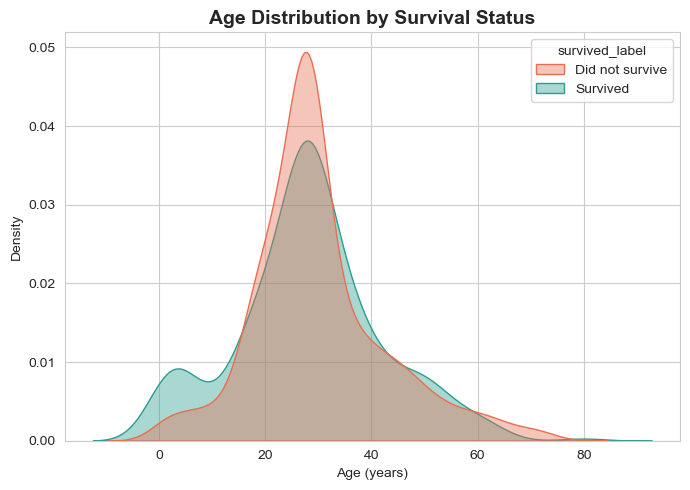

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(data=df, x='age', hue='survived_label', fill=True,
            common_norm=False, palette=palette, alpha=0.4, ax=ax)
ax.set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()


*Takeaway: young children show a visible survival bump, while the broad adult age range skews toward not surviving.*

## Chart 5 — Fare Paid by Survival Status

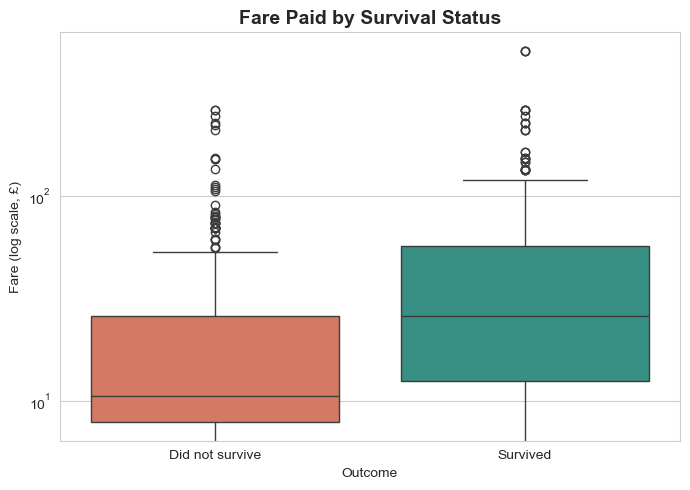

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='survived_label', y='fare', hue='survived_label',
            palette=palette, legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Fare Paid by Survival Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Fare (log scale, £)')
plt.tight_layout()
plt.show()


*Takeaway: survivors typically paid higher fares, reinforcing that class and cabin position (not just sex) shaped survival odds.*

## Chart 6 — Survival Rate by Family Size

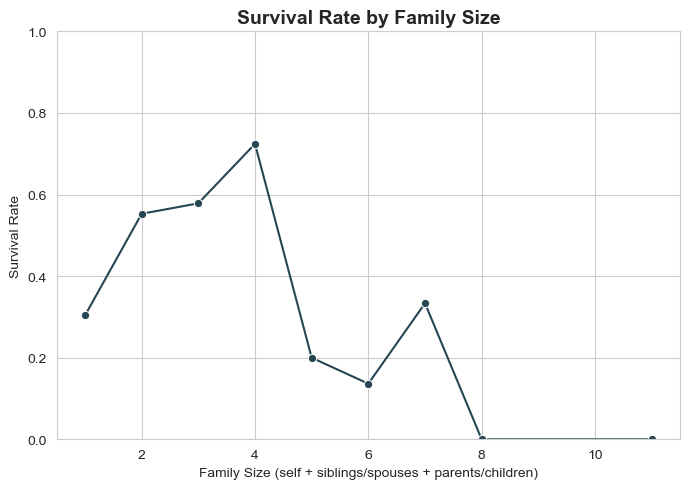

In [8]:
rate_fam = df.groupby('family_size')['survived'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=rate_fam, x='family_size', y='survived', marker='o', color='#264653', ax=ax)
ax.set_title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Family Size (self + siblings/spouses + parents/children)')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


*Takeaway: passengers travelling with a small family (2-4 members) survived more often than those travelling completely alone or in very large families.*

## Written Summary (200 words)

The Titanic dataset tells a clear, layered story about who survived and who
didn't, and the six charts above trace that story from the broadest view down
to the finer details. Overall, most passengers died, setting the baseline
against which every other pattern stands out. Sex turns out to be the single
strongest predictor: women survived at a far higher rate than men, a direct
result of the "women and children first" boarding protocol enforced during
evacuation. Passenger class adds a second, compounding layer — first-class
passengers survived much more often than third-class passengers, showing
that wealth and cabin location translated into real advantages in reaching
lifeboats. The age distribution shows a modest survival bump among young
children, consistent with the evacuation priority, while the bulk of adult
ages lean toward the "did not survive" side. Fare, closely tied to class,
confirms the same trend: survivors typically paid higher fares. Finally,
family size reveals a subtler U-shaped effect — solo travelers and those in
very large families fared worse than passengers traveling in small family
groups of two to four, likely because small groups could move and coordinate
quickly without becoming separated in the chaos. Together, these charts show
survival on the Titanic was shaped by a mix of social norms, economic status,
age, and travel-group size rather than random chance.
